# Advanced Plotting with Matplotlib, Plotly & Seaborn – My Finance BA Version
Forked from JP Morgan Chase python-training repo  
Customized by S33mi (March 2026)  
Goal: Master professional, publication-ready charts for financial analysis – correlations, time series, distributions, candlesticks, heatmaps – essential for BA reports, dashboards, and stakeholder presentations.

# Advanced Plotting: Beyond matplotlib

Alright, so our prior charts were plotted using `matplotlib` which helps us see the data, but the charts don't look amazing and aren't interactive at all. What other options do we have? [seaborn](https://seaborn.pydata.org/index.html) is a wrapper the top of `matplotlib` that makes much prettier plots (with a ton of statistical plotting capabilities) and [plotly](https://plot.ly/) is a great cross-platform plotting liberary that we can easil set up. Below we'll use `seaborn` and `plotly` to make some pretty pictures.

First, let's import some libraries.

In [40]:
#Added by S33mi
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')  # Modern default – replace 'fivethirtyeight' if used

import seaborn as sns
import pandas as pd
import yfinance as yf
import numpy as np
from ipywidgets import interact, Dropdown, Text
from datetime import datetime

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_context("notebook", font_scale=1.2)

In [41]:
import pandas as pd
import datetime as dt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

%matplotlib inline

Since we don't have access to some of the data that we do within JPM, we'll have to generate some data to plot. In this case, we're going to generate an approximation of Russell2k implied volatility and HYG (iTraxx High Yield Bond ETF) prices.

In [42]:
vols = [ 0.3, 0.06 ]
dailyVols = vols / np.sqrt( 252 )
corr = -0.4
covars = [
    [ dailyVols[ 0 ] ** 2, dailyVols[ 0 ] * dailyVols[ 1 ] * corr ],
    [ dailyVols[ 0 ] * dailyVols[ 1 ] * corr, dailyVols[ 1 ] ** 2 ]
]
randomSeries = np.random.multivariate_normal( ( 0.001, 0 ), covars, 500 ).T

In [43]:
randomSeries

array([[ 1.55853422e-02, -2.24658442e-02, -2.63168247e-02,
         2.71717913e-02,  5.86593757e-03,  3.35258241e-02,
         8.29949036e-03, -2.56696853e-02, -4.56856898e-03,
         3.73837471e-02, -7.22088484e-03,  4.33422256e-03,
        -9.05998891e-03, -2.03998201e-02, -7.02791624e-03,
        -3.80316252e-02,  8.11103465e-03,  1.47489677e-02,
         1.82667034e-02, -1.94114054e-02,  7.41542112e-03,
        -2.55272932e-02,  7.76549450e-04,  2.91390307e-03,
        -1.68808997e-02,  2.66030916e-02, -5.19077203e-02,
        -2.52254857e-02,  1.51134944e-02,  1.16710101e-02,
        -3.93433659e-02,  4.95634838e-03, -1.45237981e-02,
         2.68504611e-02, -9.28648442e-03, -1.45406521e-02,
         1.82607453e-03,  1.19514145e-02, -2.86624765e-02,
        -1.84273800e-03,  7.44790032e-03,  1.57747713e-02,
        -3.62869546e-03, -8.34717503e-03, -2.47229849e-02,
         1.21018804e-02,  1.33464491e-03, -1.05465463e-02,
         6.50147864e-03,  2.69334916e-02,  3.13579610e-0

We've got two return series, but we need to convert them to a time series for what they're meant to represent.

In [44]:
rtyVol = 0.2 * ( 1 + randomSeries[ 0 ] ).cumprod()
hygPrice = 80 * ( 1 + randomSeries[ 1 ] ).cumprod()

Let's see if they make sense... Often the easiest way to do that is to plot them. Many of the plotting libraries set up to operate / plot a `DataFrame` natively.

In [45]:
df = pd.DataFrame(np.array([rtyVol, hygPrice]).T, columns=["RTY.3m.Proxy.Implied.Vol", "HYG.spot"])

In [46]:
df.head()

,RTY.3m.Proxy.Implied.Vol,HYG.spot
0,0.2031,80.1617
1,0.1986,80.3700
2,0.1933,81.0314
3,0.1986,80.8294
4,0.1997,80.7500


<Axes: >

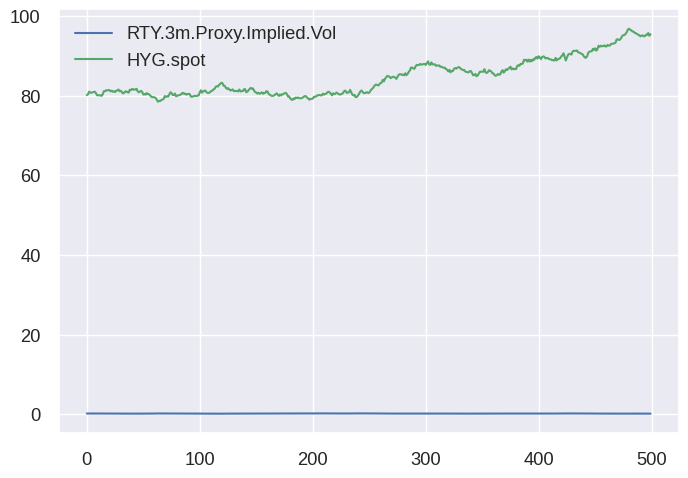

In [47]:
df.plot()

So... problem #1, these two series not similar magnitudes. We need to plot these on difference axes and while we're at it let's make it look a little better.

<Axes: >

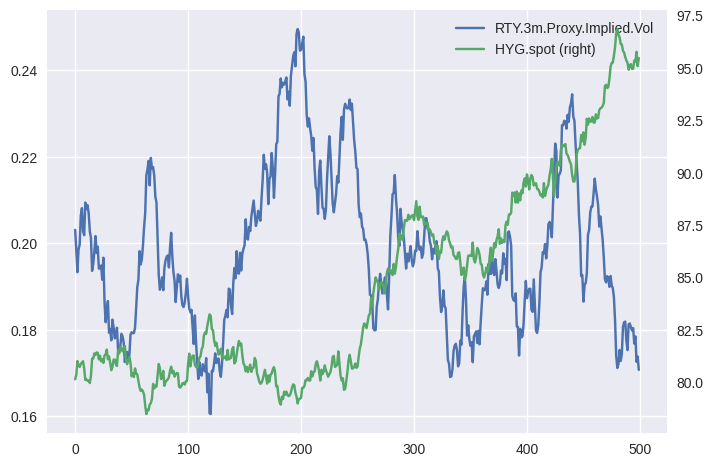

In [48]:
#plt.style.use('seaborn') #Moderen seabon doesnot work with that
#df.plot(secondary_y=["HYG.spot"], legend=True)

plt.style.use('seaborn-v0_8')           # most common replacement for plain 'seaborn'
# or any of these variants:
# plt.style.use('seaborn-v0_8-whitegrid')
# plt.style.use('seaborn-v0_8-darkgrid')
# plt.style.use('seaborn-v0_8-deep')
# plt.style.use('seaborn-v0_8-colorblind')
# etc.

df.plot(secondary_y=["HYG.spot"], legend=True)

<Axes: >

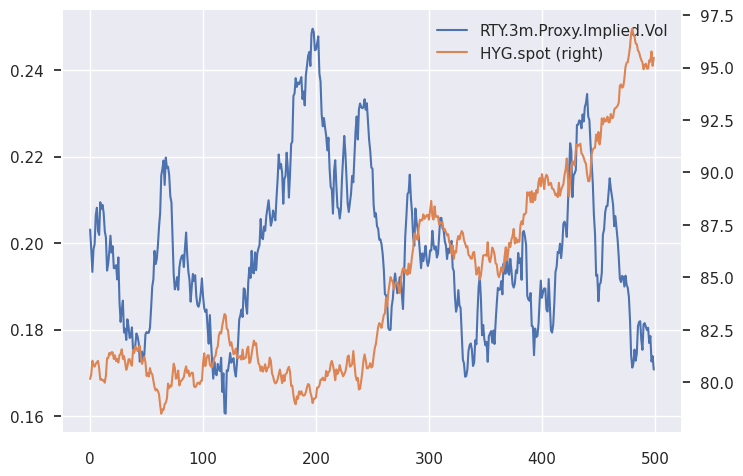

In [49]:
sns.set_theme()               # ← this applies modern seaborn defaults
# or more explicitly:
# sns.set_theme(style="darkgrid")   # or "whitegrid", "dark", "white", "ticks"

# Your plot
df.plot(secondary_y=["HYG.spot"], legend=True)
#plt.show()   # if you're not in a notebook

If we flip around RTY implied vol, we can see this inverse relationship a bit better.

<Axes: >

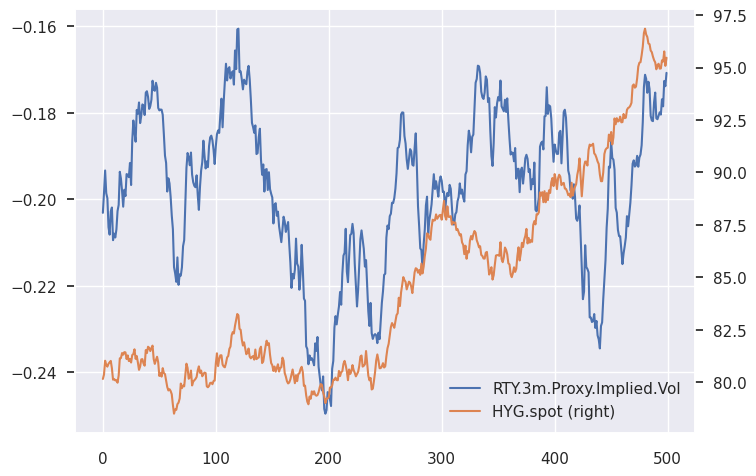

In [50]:
df["RTY.3m.Proxy.Implied.Vol"] = df["RTY.3m.Proxy.Implied.Vol"] * -1
df.plot(secondary_y=["HYG.spot"], legend=True)

We can look at the scatter on levels pretty easily with `matplotlib` using `matplotlib.pyplot.scatter`.

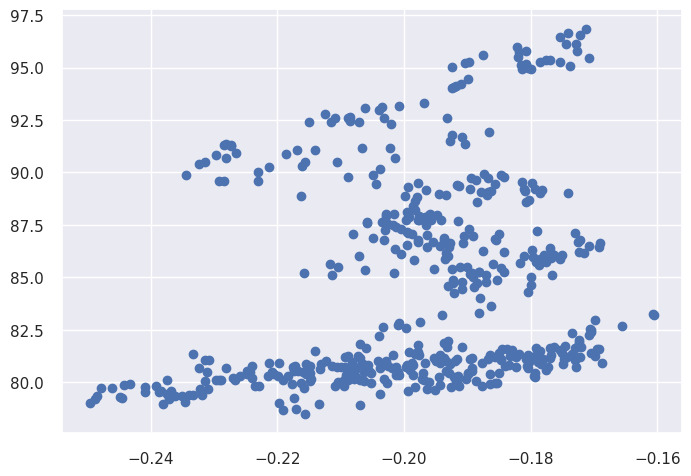

In [51]:
plt.scatter( df[ df.columns[ 0 ] ], df[ df.columns[ 1 ] ] )

It looks like there is a relationship there (there should be, we generated the series with a negative correlation). Let's explore that a bit. As we said before, `seaborn` comes with a bunch of good statistical tools. In fact, it has has quick and easy way to generate a regression plot with `sns.regplot`.

<Axes: xlabel='HYG.spot', ylabel='RTY.3m.Proxy.Implied.Vol'>

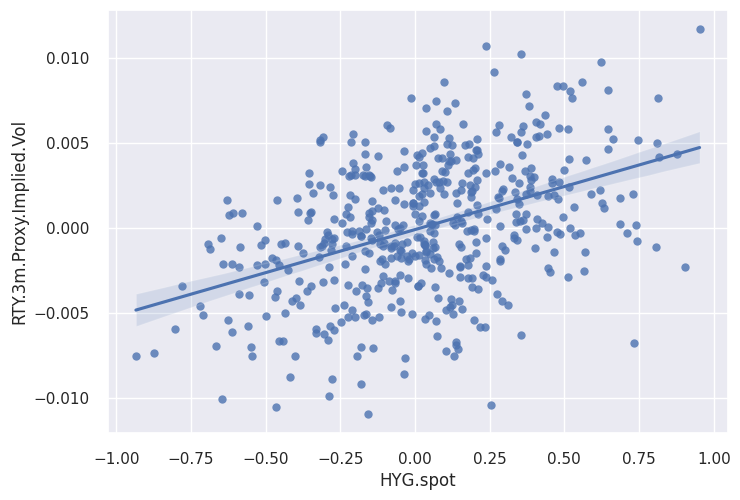

In [52]:
fig, ax = plt.subplots( sharex=True )
sns.regplot( x="HYG.spot", y="RTY.3m.Proxy.Implied.Vol", data=df.diff(), ax=ax )

Unfortunately, the underlying regression data is not exposed in `seaborn`, so we will need to generate it ourselves using `scipy`.

In [75]:
from scipy import stats

diff = df.diff().dropna()
slope, intercept, rvalue, pvalue, stderr = stats.linregress(diff["HYG.spot"], diff["RTY.3m.Proxy.Implied.Vol"])
print( "R^2 = {r:.3f}".format( r=rvalue ) )
print( 'y = {m:.3f}x {sign} {b:.3f}'.format( m=slope, sign="+" if intercept >= 0 else "-", b=abs(intercept) ) )

R^2 = 0.428
y = 0.005x - 0.000


What if I want to interact with the plot.... zoom in, inspect the values, etc. This is where `plotly` shines.

In [74]:
#Outdate Plotly Code

#from plotly.offline import download_plotlyjs, init_notebook_mode, iplot
#import plotly.tools as tls
#init_notebook_mode(connected=True)

# Here we can convert our matplotlib object to a plotly object
#plotlyFig = tls.mpl_to_plotly(fig)

# Add annotation so you have the regression stats
#plotlyFig['layout']['annotations'] = [
#    dict(
#        x=18,
#        y=-2,
#        showarrow=False,
#        text='R^2 = {:.3f}'.format( rvalue )
#    ),
#   dict(
#       x=18,
#       y=-2.6,
#        showarrow=False,
#        text='y = {m:.3f}x {sign} {b:.3f}'.format( m=slope, sign="+" if intercept >= 0 else "-", b=abs(intercept) )
#    )
#]
#iplot(plotlyFig)

In [72]:
import plotly.graph_objects as go

import plotly.io as pio

# Force Colab renderer (this fixes most "no graph shown" issues)
pio.renderers.default = 'colab'

# Make sure you have run the previous cells:
# diff = df.diff().dropna()
# slope, intercept, rvalue, pvalue, stderr = stats.linregress(
#     diff["HYG.spot"], diff["RTY.3m.Proxy.Implied.Vol"]
# )

# === Modern Plotly version ===
fig = go.Figure()

# Scatter points (hollow markers like seaborn.regplot usually shows)
fig.add_trace(go.Scatter(
    x=diff["HYG.spot"],
    y=diff["RTY.3m.Proxy.Implied.Vol"],
    mode='markers',
    marker=dict(
        size=7,
        color='#1f77b4',           # seaborn blue
        line=dict(width=1, color='#1f77b4'),
        symbol='circle-open'       # open circles (hollow)
    ),
    name='Daily Changes'
))

# Regression line
x_line = diff["HYG.spot"]
y_line = slope * x_line + intercept

fig.add_trace(go.Scatter(
    x=x_line,
    y=y_line,
    mode='lines',
    line=dict(color='red', width=2.5),
    name='Regression Line'
))

# Annotations (exactly like the original notebook)
sign = "+" if intercept >= 0 else "-"

fig.add_annotation(
    x=18, y=-2,
    text=f"R² = {rvalue**2:.3f}",
    showarrow=False,
    font=dict(size=13)
)

fig.add_annotation(
    x=18, y=-2.6,
    text=f"y = {slope:.3f}x {sign} {abs(intercept):.3f}",
    showarrow=False,
    font=dict(size=13)
)

# Layout
fig.update_layout(
    template="plotly_white",          # clean modern look
    title="HYG Spot vs RTY 3m Proxy Implied Vol (Daily Changes)",
    xaxis_title="HYG.spot daily change",
    yaxis_title="RTY.3m.Proxy.Implied.Vol daily change",
    width=900,
    height=600,
    hovermode="closest",
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show() #Try to zoom in zoom out for deeper analysis

2d plots are cool but 3d plots.... Below is an example of plotting a vol surface from start to finish.

In [68]:
c = [0.8023,0.814,0.8256,0.8372,0.8488,0.8605,0.8721,0.8837,0.8953,0.907,0.9186,0.9302,0.9419,0.9535,0.9651,0.9767,0.9884,1,1.0116,1.0233,1.0349,1.0465,1.0581,1.0698,1.0814,1.093,1.1047,1.1163,1.1279,1.1395,1.1512,1.1628,1.1744,1.186,1.1977,1.2093]
i = [ dt.datetime(2019,8,2),  dt.datetime(2019,8,9),  dt.datetime(2019,8,16),  dt.datetime(2019,8,23),  dt.datetime(2019,8,30),  dt.datetime(2019,9,6),  dt.datetime(2019,9,20),  dt.datetime(2019,10,18),  dt.datetime(2019,11,15),  dt.datetime(2019,12,20),  dt.datetime(2019,12,31),  dt.datetime(2020,1,17),  dt.datetime(2020,3,20),  dt.datetime(2020,3,31),  dt.datetime(2020,6,19) ]
d = [ [0.4244,0.4016,0.3796,0.3584,0.3381,0.3187,0.3002,0.2827,0.2662,0.2508,0.2363,0.2229,0.2105,0.1991,0.1888,0.1794,0.171,0.1636,0.157,0.1513,0.1465,0.1425,0.1393,0.1368,0.135,0.1338,0.1331,0.1329,0.133,0.1334,0.1341,0.135,0.136,0.1372,0.1384,0.1396],
    [0.4006,0.3777,0.3556,0.3343,0.3139,0.2944,0.2759,0.2583,0.2418,0.2263,0.2118,0.1983,0.1859,0.1745,0.1641,0.1547,0.1463,0.1388,0.1322,0.1265,0.1216,0.1176,0.1143,0.1118,0.11,0.1088,0.1081,0.1078,0.108,0.1084,0.1092,0.1101,0.1112,0.1123,0.1136,0.1149],
    [0.3431,0.3257,0.3089,0.2927,0.277,0.2621,0.2477,0.2341,0.2212,0.2089,0.1974,0.1866,0.1765,0.1671,0.1584,0.1504,0.1431,0.1364,0.1303,0.1248,0.1198,0.1154,0.1116,0.1083,0.1055,0.1032,0.1013,0.0998,0.0986,0.0977,0.0971,0.0966,0.0964,0.0963,0.0963,0.0965],
    [0.3124,0.298,0.284,0.2705,0.2574,0.2449,0.2328,0.2213,0.2104,0.1999,0.1901,0.1807,0.1719,0.1637,0.156,0.1488,0.1421,0.136,0.1304,0.1253,0.1206,0.1165,0.1129,0.1098,0.1072,0.1049,0.1031,0.1015,0.1003,0.0994,0.0988,0.0983,0.098,0.0979,0.0978,0.0979],
    [0.2955,0.283,0.2708,0.259,0.2475,0.2365,0.2259,0.2158,0.206,0.1968,0.1879,0.1795,0.1716,0.1641,0.1571,0.1505,0.1443,0.1385,0.1332,0.1284,0.124,0.1201,0.1167,0.1137,0.1111,0.1089,0.1071,0.1056,0.1044,0.1034,0.1027,0.1022,0.1019,0.1018,0.1017,0.1018],
    [0.2866,0.2752,0.264,0.2532,0.2427,0.2326,0.2228,0.2134,0.2044,0.1958,0.1876,0.1798,0.1724,0.1653,0.1587,0.1524,0.1465,0.141,0.1359,0.1313,0.1271,0.1233,0.12,0.1171,0.1145,0.1124,0.1106,0.1091,0.1079,0.1069,0.1062,0.1057,0.1054,0.1052,0.1051,0.1051],
    [0.2729,0.2632,0.2538,0.2446,0.2357,0.227,0.2187,0.2106,0.2028,0.1954,0.1882,0.1813,0.1748,0.1685,0.1626,0.1569,0.1516,0.1465,0.1418,0.1376,0.1336,0.1301,0.127,0.1242,0.1218,0.1197,0.1179,0.1164,0.1152,0.1143,0.1135,0.113,0.1126,0.1124,0.1122,0.1122],
    [0.2548,0.2473,0.24,0.2329,0.226,0.2192,0.2126,0.2063,0.2001,0.1941,0.1883,0.1827,0.1773,0.1721,0.167,0.1622,0.1576,0.1532,0.149,0.1452,0.1416,0.1383,0.1354,0.1327,0.1303,0.1281,0.1262,0.1246,0.1232,0.122,0.121,0.1202,0.1195,0.119,0.1186,0.1183],
    [0.2482,0.242,0.2359,0.2299,0.2241,0.2184,0.2128,0.2074,0.2021,0.1969,0.1919,0.187,0.1823,0.1777,0.1733,0.169,0.1649,0.1608,0.157,0.1535,0.1501,0.1471,0.1442,0.1415,0.1391,0.1369,0.135,0.1332,0.1316,0.1303,0.1291,0.128,0.1271,0.1263,0.1257,0.1252],
    [0.2331,0.2278,0.2227,0.2176,0.2127,0.2078,0.2031,0.1984,0.1939,0.1895,0.1851,0.1809,0.1768,0.1728,0.1689,0.1652,0.1615,0.158,0.1547,0.1516,0.1486,0.1459,0.1433,0.1409,0.1387,0.1367,0.1349,0.1332,0.1317,0.1303,0.1291,0.128,0.127,0.1261,0.1254,0.1247],
    [0.2313,0.2262,0.2212,0.2163,0.2115,0.2068,0.2022,0.1977,0.1932,0.1889,0.1847,0.1806,0.1766,0.1727,0.1689,0.1653,0.1617,0.1582,0.155,0.152,0.1491,0.1464,0.1438,0.1415,0.1393,0.1373,0.1354,0.1337,0.1322,0.1308,0.1296,0.1284,0.1274,0.1266,0.1258,0.1251],
    [0.2302,0.2253,0.2206,0.216,0.2114,0.2069,0.2026,0.1983,0.1941,0.19,0.186,0.1821,0.1783,0.1745,0.1709,0.1674,0.164,0.1607,0.1576,0.1546,0.1518,0.1492,0.1467,0.1444,0.1423,0.1403,0.1384,0.1367,0.1351,0.1337,0.1324,0.1313,0.1302,0.1293,0.1285,0.1277],
    [0.229,0.2249,0.2209,0.2169,0.213,0.2091,0.2054,0.2017,0.1981,0.1946,0.1911,0.1877,0.1845,0.1812,0.1781,0.175,0.172,0.1691,0.1664,0.1637,0.1611,0.1587,0.1563,0.1541,0.152,0.15,0.148,0.1462,0.1445,0.143,0.1415,0.1401,0.1388,0.1376,0.1365,0.1355],
    [0.2289,0.2249,0.2209,0.2171,0.2133,0.2096,0.2059,0.2023,0.1988,0.1953,0.192,0.1887,0.1855,0.1823,0.1793,0.1763,0.1733,0.1705,0.1678,0.1651,0.1626,0.1602,0.1579,0.1557,0.1535,0.1515,0.1496,0.1478,0.1461,0.1445,0.143,0.1415,0.1402,0.139,0.1379,0.1368],
    [0.2239,0.2207,0.2175,0.2143,0.2112,0.2082,0.2051,0.2022,0.1993,0.1964,0.1936,0.1909,0.1882,0.1855,0.1829,0.1804,0.1779,0.1755,0.1731,0.1708,0.1685,0.1663,0.1642,0.1622,0.1601,0.1582,0.1563,0.1545,0.1527,0.151,0.1494,0.1478,0.1464,0.1449,0.1436,0.1423]
]
df2 = pd.DataFrame(d, columns=c, index=i)

In [69]:
df2.head()

,0.8023,0.8140,0.8256,0.8372,0.8488,0.8605,0.8721,0.8837,0.8953,0.9070,...,1.1047,1.1163,1.1279,1.1395,1.1512,1.1628,1.1744,1.1860,1.1977,1.2093
2019-08-02,0.4244,0.4016,0.3796,0.3584,0.3381,0.3187,0.3002,0.2827,0.2662,0.2508,...,0.1331,0.1329,0.1330,0.1334,0.1341,0.1350,0.1360,0.1372,0.1384,0.1396
2019-08-09,0.4006,0.3777,0.3556,0.3343,0.3139,0.2944,0.2759,0.2583,0.2418,0.2263,...,0.1081,0.1078,0.1080,0.1084,0.1092,0.1101,0.1112,0.1123,0.1136,0.1149
2019-08-16,0.3431,0.3257,0.3089,0.2927,0.2770,0.2621,0.2477,0.2341,0.2212,0.2089,...,0.1013,0.0998,0.0986,0.0977,0.0971,0.0966,0.0964,0.0963,0.0963,0.0965
2019-08-23,0.3124,0.2980,0.2840,0.2705,0.2574,0.2449,0.2328,0.2213,0.2104,0.1999,...,0.1031,0.1015,0.1003,0.0994,0.0988,0.0983,0.0980,0.0979,0.0978,0.0979
2019-08-30,0.2955,0.2830,0.2708,0.2590,0.2475,0.2365,0.2259,0.2158,0.2060,0.1968,...,0.1071,0.1056,0.1044,0.1034,0.1027,0.1022,0.1019,0.1018,0.1017,0.1018


Support for third party widgets will remain active for the duration of the session. To disable support:

In [70]:
from google.colab import output
output.enable_custom_widget_manager()   # ← This is what you need (enable, not disable)

In [80]:
import plotly.graph_objs as go

fig = go.Figure(
    data=[ go.Surface(
        z=df2.values.tolist(),
        y=df2.columns.values,
        x=df2.index.astype(str).values.tolist()
    )],
    layout=dict(
        title = 'Vol Surface',
        autosize = True,
        width = 900,
        height = 700,
        margin = dict(
            l = 65,
            r = 50,
            b = 65,
            t = 90
        ),
        scene = dict(
            aspectratio = dict(
                x = 1,
                y = 1,
                z = 0.667
            )
        )
    ))

#go.FigureWidget(fig) #doesnot work in colabs
fig.show() #Show figure/output/graph
#End of orignal notebook

In case you want to keep saperate the figure data and layout style

In [78]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'colab'

# 3D Volatility Surface
fig = go.Figure(
    data=[go.Surface(
        z=df2.values.tolist(),
        y=df2.columns.values,
        x=df2.index.astype(str).values.tolist()
    )]
)

fig.update_layout(
    title='Vol Surface',
    autosize=True,
    width=950,
    height=700,
    margin=dict(l=65, r=50, b=65, t=90),
    scene=dict(
        xaxis_title='Expiration Date',
        yaxis_title='Tenor / Strike',
        zaxis_title='Implied Volatility',
        camera=dict(eye=dict(x=1.8, y=1.8, z=1.2))   # nicer viewing angle
    ),
    template="plotly_white"
)

fig.show()
#End of orignal notebook

# My Additions – Finance & Business Analyst Focused Extensions
# (original JP Morgan examples remain unchanged above)


These cells demonstrate how the same Matplotlib / Seaborn techniques can be applied to real financial time-series data.
We use yfinance to fetch live stock prices (local + global tickers).

In [81]:
# Real financial data for the examples below

import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load Real Stock Data for Plotting Examples
Fetch global stocks (from notebook 6 style) – perfect for realistic charts.

In [82]:
tickers = ['JPM', 'TSLA', 'FROTO.IS', 'AMZN', 'AAPL', 'MSFT']

print("Fetching adjusted close prices...")
data = yf.download(tickers, start="2024-01-01", progress=False)['Close']

returns = data.pct_change().dropna()

print("\nLast 5 rows:")
display(returns.tail())

print("\nShape:", returns.shape)

Fetching adjusted close prices...


/tmp/ipykernel_8357/643189961.py:4: FutureWarning:

YF.download() has changed argument auto_adjust default to True




Last 5 rows:


/tmp/ipykernel_8357/643189961.py:6: FutureWarning:

The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



Ticker,AAPL,AMZN,FROTO.IS,JPM,MSFT,TSLA
Date,,,,,,
2026-03-17,0.0056,0.0163,0.0218,0.0026,-0.0014,0.0094
2026-03-18,-0.0169,-0.0248,-0.0204,0.0030,-0.0191,-0.0163
2026-03-19,-0.0039,-0.0053,0.0388,0.0008,-0.0071,-0.0318
2026-03-20,-0.0039,-0.0162,0.0000,-0.0049,-0.0184,-0.0324
2026-03-23,0.0141,0.0232,-0.0082,0.0117,0.0030,0.0350



Shape: (576, 6)


/tmp/ipykernel_8357/3455986531.py:10: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



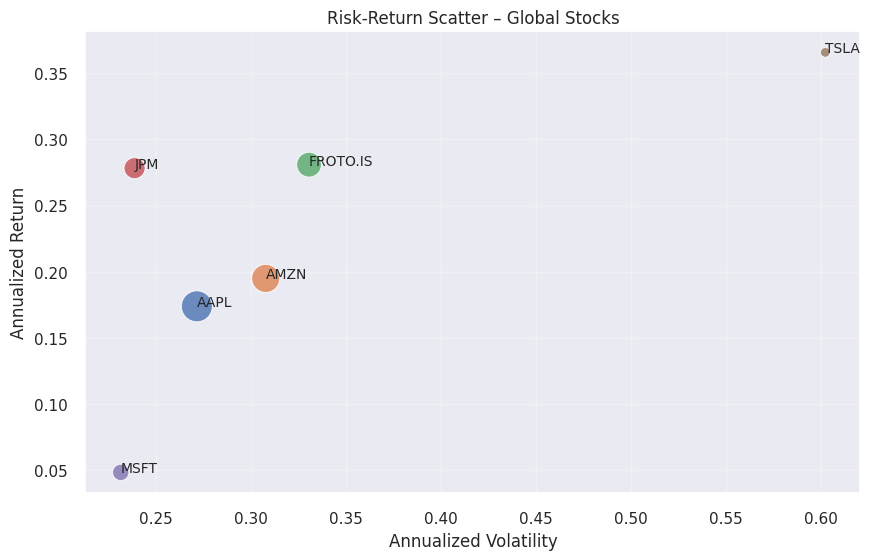

In [83]:
# Example: Returns vs Volatility (scatter with size = avg volume)
vol = returns.std() * np.sqrt(252)
avg_ret = returns.mean() * 252
vol_df = pd.DataFrame({'Annual Return': avg_ret, 'Annual Vol': vol})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=vol_df, x='Annual Vol', y='Annual Return', size=vol_df.index, hue=vol_df.index,
                sizes=(50, 500), legend=False, alpha=0.8)
for i, txt in enumerate(vol_df.index):
    plt.annotate(txt, (vol_df['Annual Vol'][i], vol_df['Annual Return'][i]), fontsize=10)
plt.title('Risk-Return Scatter – Global Stocks')
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Return')
plt.grid(True, alpha=0.3)
plt.show()

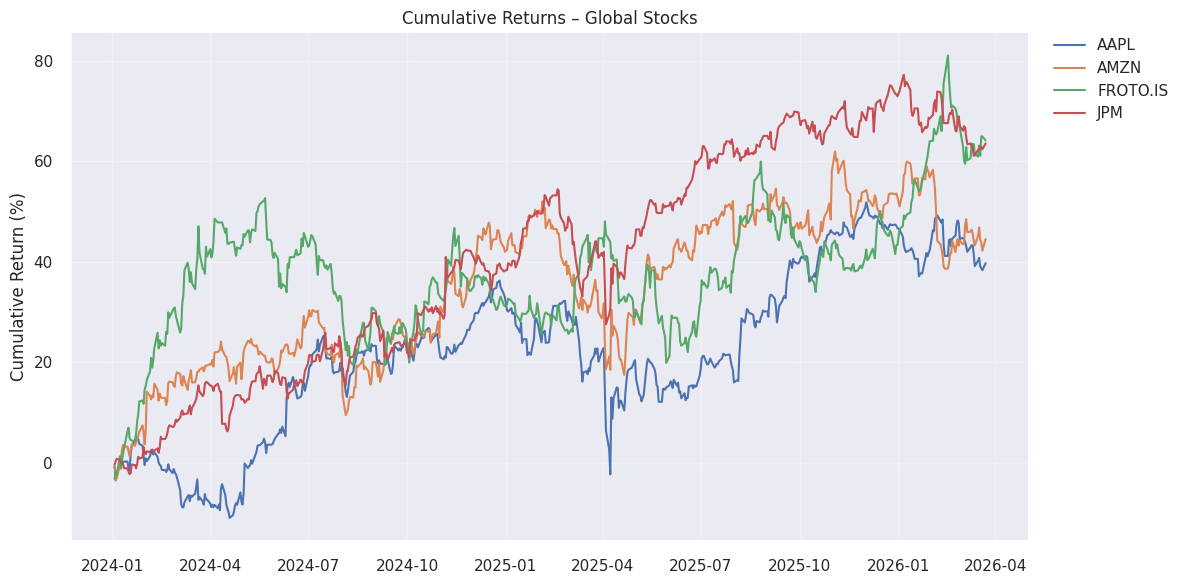

In [84]:
# Multi-line plot with legend outside
plt.figure(figsize=(12, 6))
for col in returns.columns[:4]:           # show first 4 tickers
    plt.plot(returns.index, returns[col].cumsum()*100, label=col)

plt.title("Cumulative Returns – Global Stocks")
plt.ylabel("Cumulative Return (%)")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

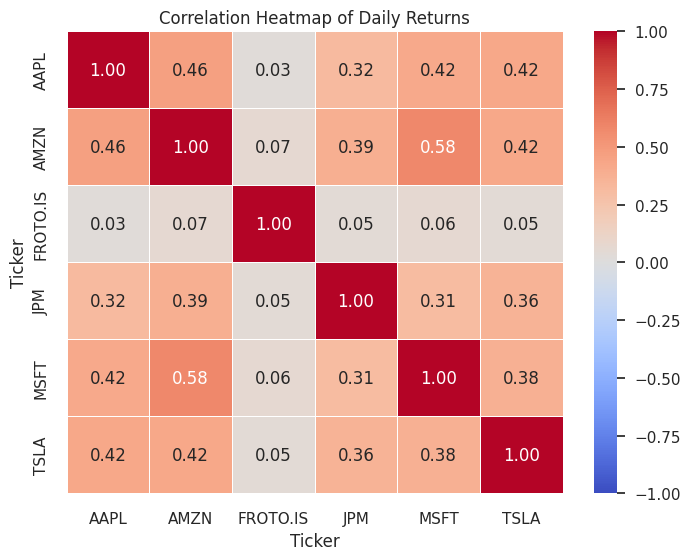

In [86]:
plt.figure(figsize=(8, 6))
corr = returns.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Daily Returns')
plt.show()

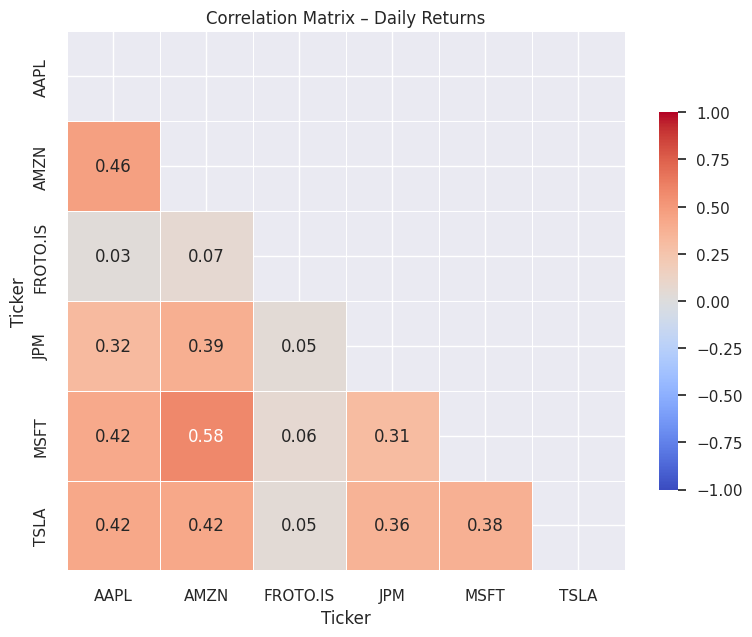

In [93]:
# Masked Correlation heatmap of daily returns
plt.figure(figsize=(9, 7))
corr = returns.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1,
    linewidths=0.6, cbar_kws={"shrink": 0.7}
)
plt.title("Correlation Matrix – Daily Returns")
plt.show()

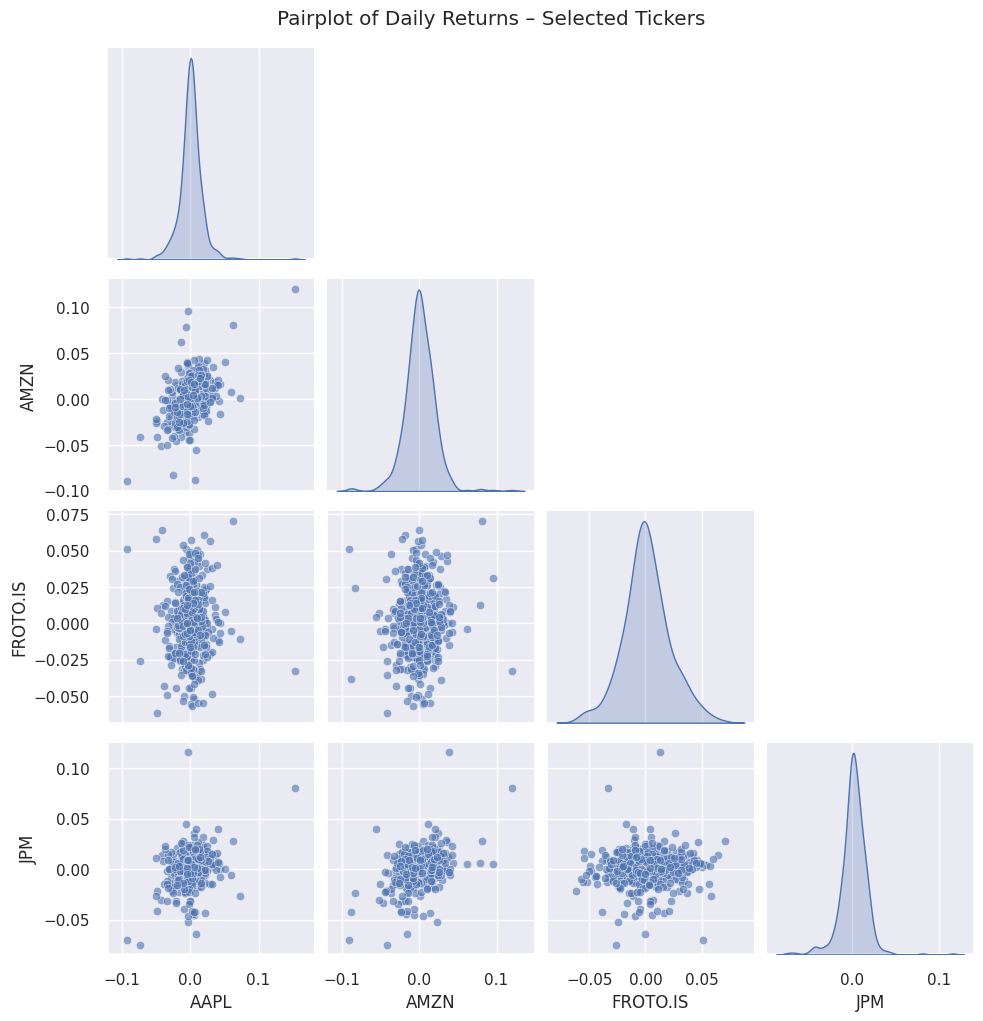

In [94]:
# Pairplot – shows distributions + scatter relationships
sns.pairplot(
    returns.iloc[:, :4],           # limit to 4 tickers to avoid too many plots
    diag_kind='kde',
    plot_kws={'alpha':0.6},
    corner=True
)
plt.suptitle("Pairplot of Daily Returns – Selected Tickers", y=1.02)
plt.show()

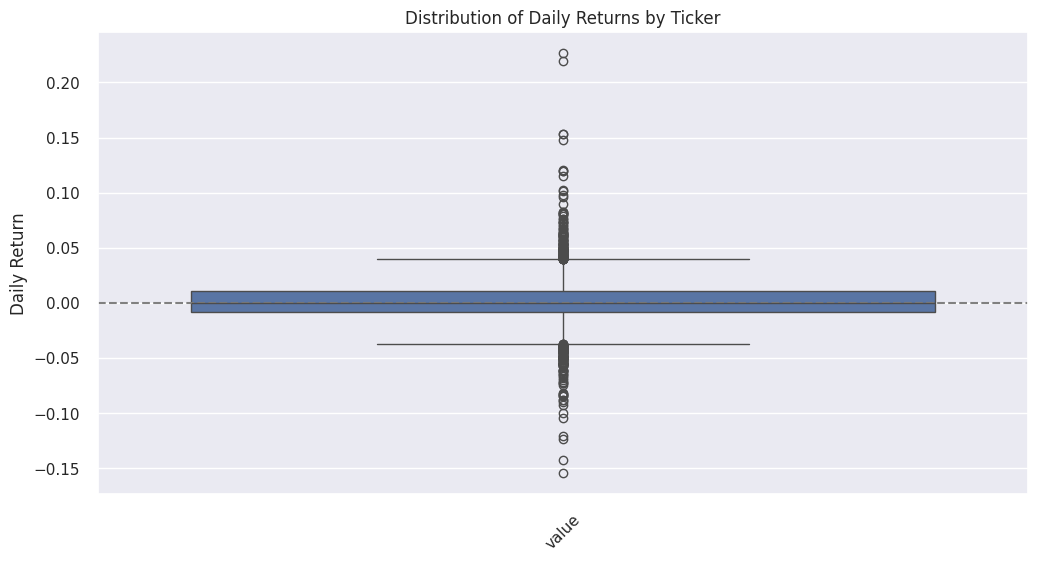

In [98]:
#Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=returns.melt()) #, x='variable', y='value')
plt.title('Distribution of Daily Returns by Ticker')
plt.ylabel('Daily Return')
plt.xticks(rotation=45)
plt.axhline(0, color='gray', linestyle='--')
plt.show()

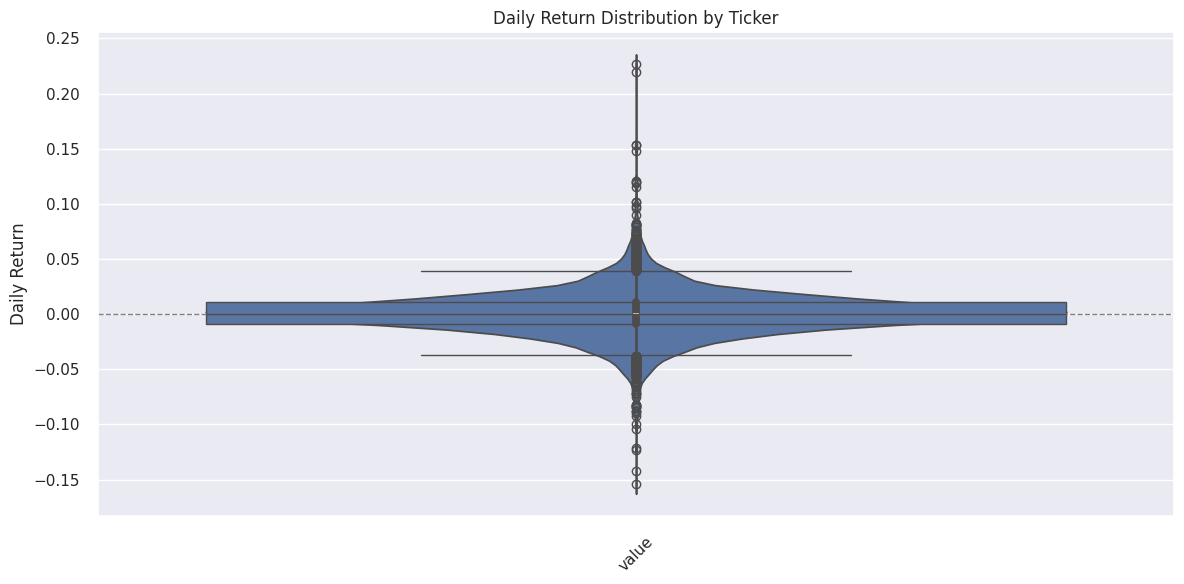

In [95]:
# Box + violin – comparing return distributions
plt.figure(figsize=(12, 6))

sns.boxplot(data=returns.melt())#, x='variable', y='value', width=0.4, fliersize=3)
sns.violinplot(data=returns.melt())#, x='variable', y='value', inner=None, color='lightgray', alpha=0.4)

plt.axhline(0, color='gray', linestyle='--', lw=1)
plt.title("Daily Return Distribution by Ticker")
plt.ylabel("Daily Return")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Interactive Plot Explorer

In [106]:
@interact(ticker=Dropdown(options=tickers, value='FROTO.IS', description='Select Ticker'))
def plot_ticker(ticker):
    df_single = yf.download(ticker, start="2024-01-01", progress=False)['Close']
    df_single.plot(figsize=(10, 5), title=f'{ticker} Adjusted Close Price')
    plt.ylabel('Price')
    plt.grid(True, alpha=0.3)
    plt.show()

interactive(children=(Dropdown(description='Select Ticker', index=2, options=('JPM', 'TSLA', 'FROTO.IS', 'AMZN…

## Finance-Specific Advanced Plots

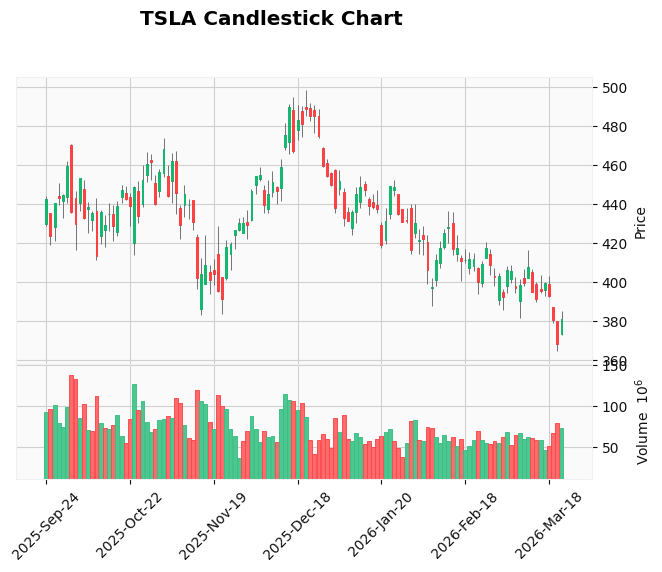

In [103]:
# Candlestick for single stock (requires mplfinance – install if needed)
!pip install mplfinance -q
import mplfinance as mpf

ticker = 'TSLA'
stock = yf.download(ticker, period="6mo", progress=False,
                    auto_adjust=True,
                    multi_level_index=False)
mpf.plot(stock, type='candle', style='yahoo', volume=True, title=f'{ticker} Candlestick Chart')

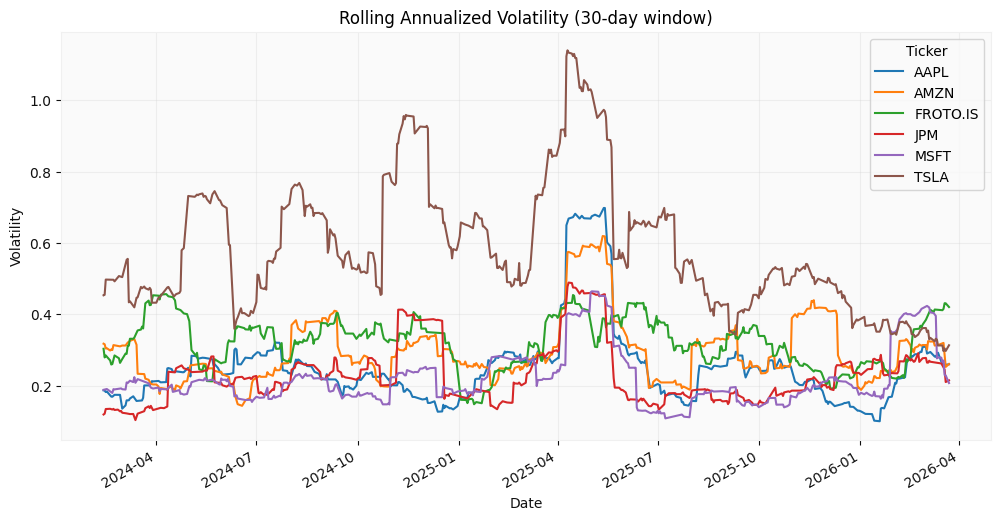

In [104]:
# Rolling 30-day volatility + mean return
rolling_vol = returns.rolling(30).std() * np.sqrt(252)
rolling_vol.plot(figsize=(12, 6), title='Rolling Annualized Volatility (30-day window)')
plt.ylabel('Volatility')
plt.grid(True, alpha=0.3)
plt.show()

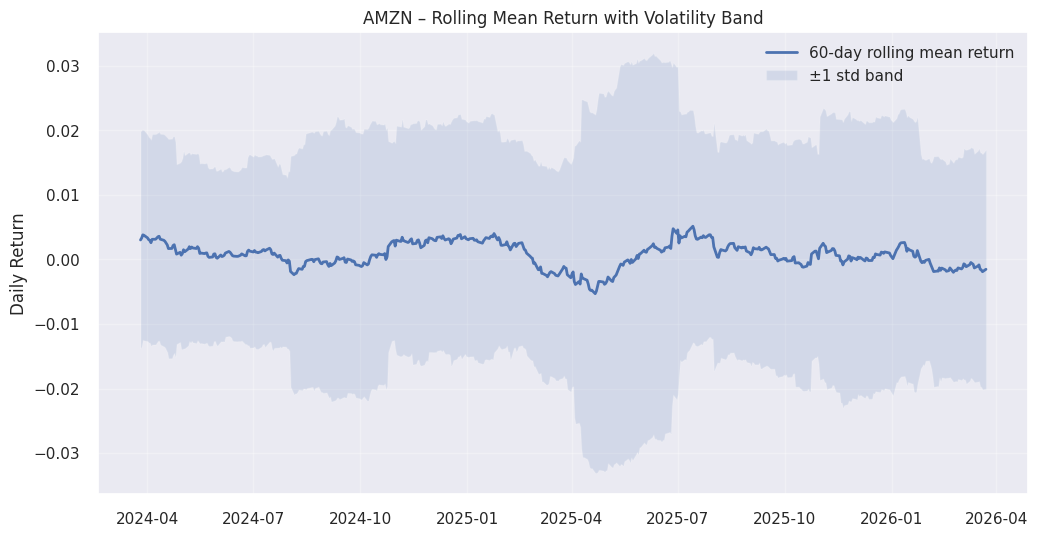

In [99]:
# Rolling 60-day mean & std of returns
rolling_mean = returns.rolling(60).mean()
rolling_std  = returns.rolling(60).std()

plt.figure(figsize=(12, 6))
plt.plot(rolling_mean['AMZN'], label='60-day rolling mean return', lw=2)
plt.fill_between(
    rolling_mean.index,
    rolling_mean['AMZN'] - rolling_std['AMZN'],
    rolling_mean['AMZN'] + rolling_std['AMZN'],
    alpha=0.15, label='±1 std band'
)
plt.title("AMZN – Rolling Mean Return with Volatility Band")
plt.ylabel("Daily Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

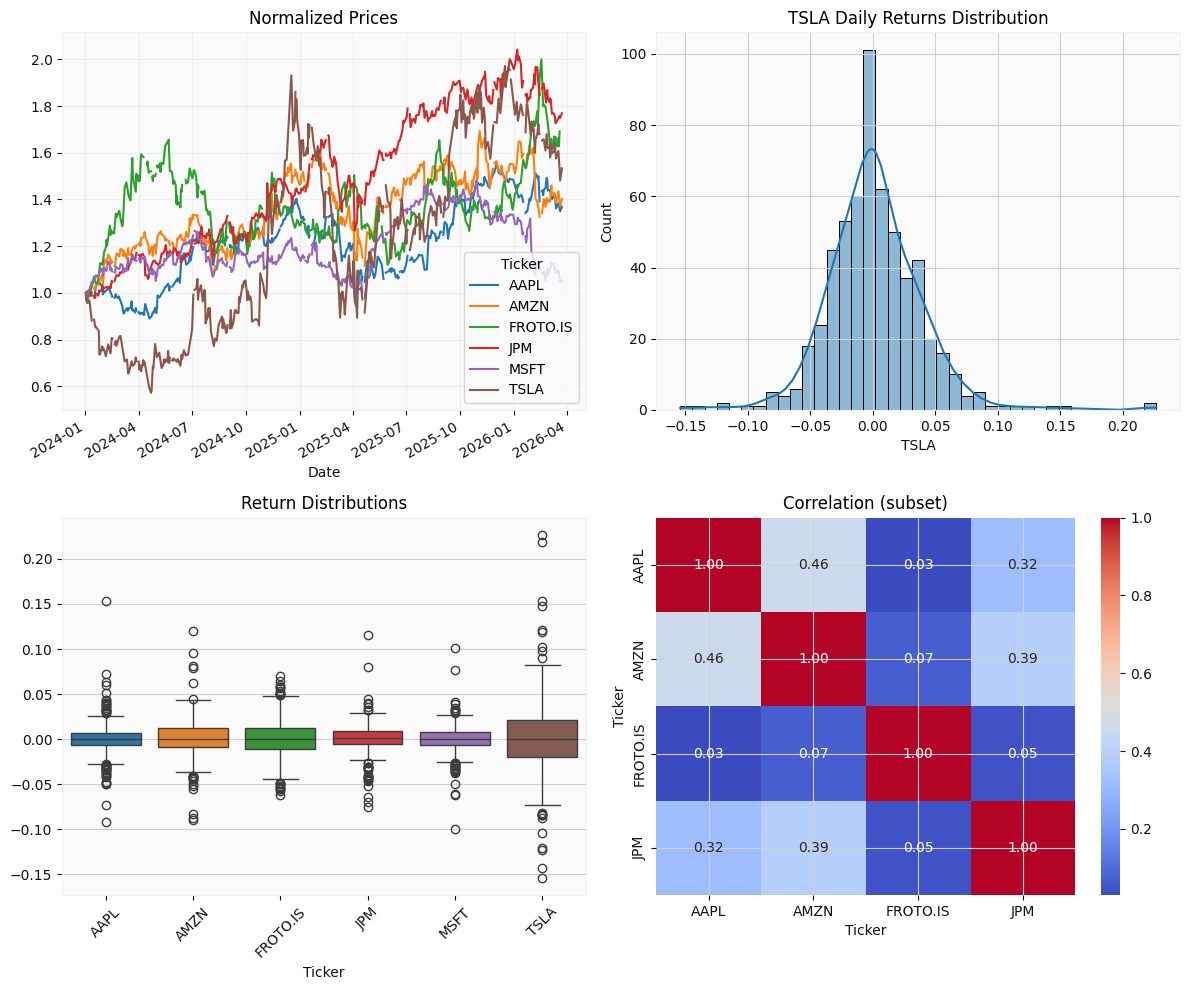

In [112]:
# 2×2 grid: price, returns hist, boxplot, correlation heatmap snippet
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top-left: normalized prices
(data / data.iloc[0]).plot(ax=axes[0,0], title="Normalized Prices")
axes[0,0].grid(True, alpha=0.3)

# Top-right: histogram of returns
sns.histplot(returns['TSLA'], kde=True, ax=axes[0,1])
axes[0,1].set_title("TSLA Daily Returns Distribution")

# Bottom-left: boxplot
sns.boxplot(data=returns, ax=axes[1,0])
axes[1,0].set_title("Return Distributions")
axes[1,0].tick_params(axis='x', rotation=45)

# Bottom-right: small correlation heatmap
sns.heatmap(returns.corr().iloc[:4,:4], annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title("Correlation (subset)")

plt.tight_layout()
plt.show()

## Summary – What I added on top of the original notebook

• Modify the old JPMC notebook as per current avaiable Ploty version

• Real time global stock data fetched via yfinance

• Correlation heatmap

• Pairplot & violin/box comparison

• Rolling volatility bands

• Candlestick for single stock

• Interactive plot explorer

• Subplots combining multiple views

### Quick BA exercises you can try:
1. Replace tickers with crypto → 'BTC-USD', 'ETH-USD'
2. Add annotations (max drawdown date, big news events)
3. Create a dashboard-style figure with 4–6 small plots
4. Export your favorite chart: `plt.savefig('psx_correlation_heatmap.png', dpi=300, bbox_inches='tight')`

These techniques are frequently used when preparing management reports, risk overviews, or investment comparison slides.